# 02 · Grayscale quantization

Reduce grayscale intensity precision to 2, 4, 8, and 16 levels without changing image dimensions.

**Inputs:** two web photographs, [NASA astronaut](https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.astronaut) and [coffee by Rachel Michetti](https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.coffee). Original files, source URLs, credits, and checksums are in [assets/](assets/). Both photographs are processed at their original dimensions.

**Group:** Nmertgules and Iliya.

The figures and measurements below are saved outputs from an actual execution. Use Restart Kernel and Run All to reproduce them.

## 1. Load and verify the photographs

The repository includes the images. If this notebook is opened alone in Colab, the same files are downloaded from the versioned URLs and checked against SHA-256 hashes.

In [1]:
%matplotlib inline
from pathlib import Path
from urllib.request import urlopen
import hashlib
import json
from time import perf_counter_ns

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("png")
plt.rcParams.update({
    "figure.dpi": 95, "font.family": "DejaVu Sans", "font.size": 10,
    "axes.titlesize": 11, "figure.facecolor": "white", "axes.spines.top": False,
    "axes.spines.right": False,
})
SOURCES = [{'name': 'astronaut', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/astronaut.png', 'sha256': '88431cd9653ccd539741b555fb0a46b61558b301d4110412b5bc28b5e3ea6cb5', 'bytes': 791555, 'credit': 'NASA', 'license': 'Public domain', 'license_reference': 'https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.astronaut'}, {'name': 'coffee', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/coffee.png', 'sha256': 'cc02f8ca188b167c775a7101b5d767d1e71792cf762c33d6fa15a4599b5a8de7', 'bytes': 466706, 'credit': 'Rachel Michetti, courtesy of Pikolo Espresso Bar', 'license': 'CC0 1.0', 'license_reference': 'https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.coffee'}]
# Works from the repository root, from week2/, and in a standalone Colab notebook.
asset_dir = next((p for p in (Path("assets"), Path("week2/assets"))
                  if p.is_dir()), Path("assets"))
asset_dir.mkdir(parents=True, exist_ok=True)
images = {}
for source in SOURCES:
    path = asset_dir / (source["name"] + ".png")
    if not path.is_file():
        with urlopen(source["url"], timeout=45) as response:
            path.write_bytes(response.read())
    raw = path.read_bytes()
    assert hashlib.sha256(raw).hexdigest() == source["sha256"], f"Photo checksum mismatch: {path.name}"
    bgr = cv2.imdecode(np.frombuffer(raw, dtype=np.uint8), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f"Cannot decode photograph: {path.name}")
    images[source["name"]] = {
        "rgb": cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB),
        "gray": cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY),
    }
    print(f"Loaded {source['name']}: {bgr.shape[1]} x {bgr.shape[0]} pixels; SHA-256 verified")

def show_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines += ["| " + " | ".join(map(str, row)) + " |" for row in rows]
    display(Markdown("\n".join(lines)))

def show_image(ax, image, title, vmax=255):
    ax.imshow(image, cmap="gray" if image.ndim == 2 else None,
              vmin=0 if image.ndim == 2 else None,
              vmax=vmax if image.ndim == 2 else None, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")

def show_figure(fig):
    display(fig)
    plt.close(fig)

RESULTS = {}

Loaded astronaut: 512 x 512 pixels; SHA-256 verified
Loaded coffee: 600 x 400 pixels; SHA-256 verified


## 2. Method

For L levels, bin width = 256/L and Q(x) = floor(x/bin width) × bin width. This lower-edge quantizer produces 0 and 128 for L=2; it does not stretch the highest bin to white. All grayscale panels share the 0–255 display range.

In [2]:
LEVELS = (2, 4, 8, 16)
def quantize(image, levels):
    if not isinstance(levels, int) or not 1 <= levels <= 256 or 256 % levels:
        raise ValueError("Levels must be an integer divisor of 256")
    width = 256 // levels
    return ((image.astype(np.uint16) // width) * width).astype(np.uint8)

## 3. Results on both photographs

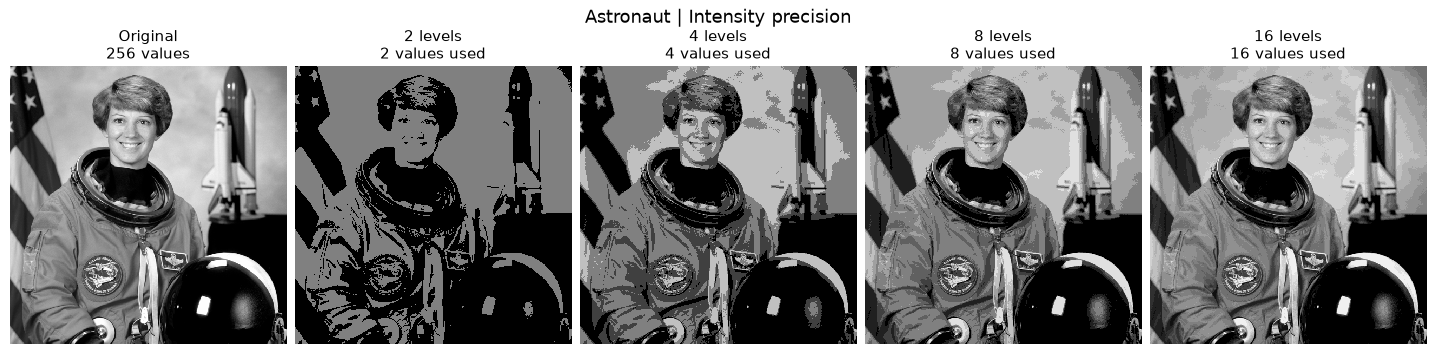

| Available levels | Observed levels | Mean absolute error | Maximum error |
| --- | --- | --- | --- |
| 2 | 2 | 50.366 | 127 |
| 4 | 4 | 26.226 | 63 |
| 8 | 8 | 13.368 | 31 |
| 16 | 16 | 6.534 | 15 |

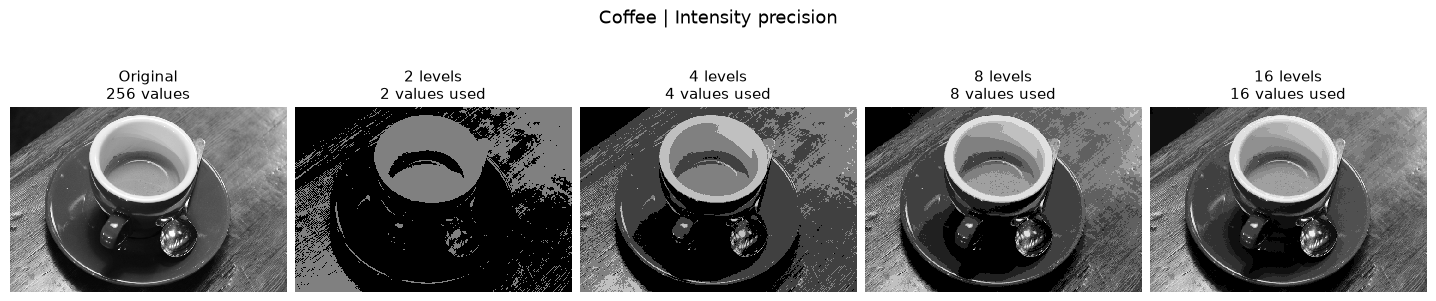

| Available levels | Observed levels | Mean absolute error | Maximum error |
| --- | --- | --- | --- |
| 2 | 2 | 60.823 | 127 |
| 4 | 4 | 28.949 | 63 |
| 8 | 8 | 15.644 | 31 |
| 16 | 16 | 7.713 | 15 |

In [3]:
for name, photo in images.items():
    image = photo["gray"]
    fig, axes = plt.subplots(1, 5, figsize=(15, 3.8), layout="constrained")
    show_image(axes[0], image, f"Original\n{np.unique(image).size} values")
    rows, metrics = [], []
    for ax, levels in zip(axes[1:], LEVELS):
        result = quantize(image, levels)
        error = image.astype(np.int16) - result.astype(np.int16)
        unique = np.unique(result)
        assert result.shape == image.shape and result.dtype == np.uint8
        assert unique.size <= levels and error.min() >= 0 and error.max() < 256 // levels
        show_image(ax, result, f"{levels} levels\n{unique.size} values used")
        mae = float(error.mean())
        rows.append([levels, unique.size, f"{mae:.3f}", int(error.max())])
        metrics.append({"levels": levels, "observed_levels": int(unique.size), "mean_absolute_error": mae, "max_error": int(error.max())})
    fig.suptitle(name.title() + " | Intensity precision", fontsize=14)
    show_figure(fig)
    show_table(["Available levels", "Observed levels", "Mean absolute error", "Maximum error"], rows)
    RESULTS[name] = metrics

## 4. Interpretation

Fewer levels produce wider bands and larger quantization error. An image may use fewer than the available levels when it does not contain every intensity bin; the full 0–255 ramp below verifies the complete quantizer mapping independently of photo content.

In [4]:
ramp = np.arange(256, dtype=np.uint8).reshape(16, 16)
for levels in (1, 2, 4, 8, 16, 256):
    assert np.array_equal(np.unique(quantize(ramp, levels)), np.arange(levels) * (256 // levels))
print("PASS: both photographs, quantization error bounds, and all 256 input intensities.")

PASS: both photographs, quantization error bounds, and all 256 input intensities.
